Epoch 1/10
1/1 [==============================] - 1s 1s/step - loss: 0.7490 - accuracy: 0.2500 - val_loss: 2.3513 - val_accuracy: 0.0000e+00
Epoch 2/10
1/1 [==============================] - 0s 151ms/step - loss: 0.6895 - accuracy: 0.7500 - val_loss: 1.6300 - val_accuracy: 0.0000e+00
Epoch 3/10
1/1 [==============================] - 0s 154ms/step - loss: 0.5045 - accuracy: 0.7500 - val_loss: 1.2451 - val_accuracy: 0.0000e+00
Epoch 4/10
1/1 [==============================] - 0s 214ms/step - loss: 0.3488 - accuracy: 1.0000 - val_loss: 1.7789 - val_accuracy: 0.0000e+00
Epoch 5/10
1/1 [==============================] - 0s 156ms/step - loss: 0.3824 - accuracy: 0.7500 - val_loss: 2.5106 - val_accuracy: 0.0000e+00
Epoch 6/10
1/1 [==============================] - 0s 150ms/step - loss: 0.2727 - accuracy: 0.7500 - val_loss: 1.8822 - val_accuracy: 0.0000e+00
Epoch 7/10
1/1 [==============================] - 0s 193ms/step - loss: 0.2510 - accuracy: 1.0000 - val_loss: 1.2603 - val_accuracy: 0.0000

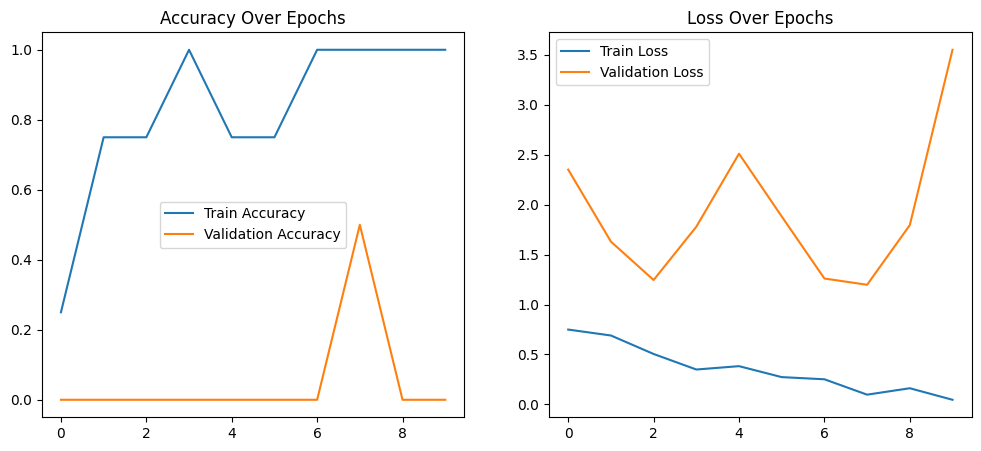

Model saved as mask_detection_model.keras


In [8]:
# Step 1: Import Libraries
import numpy as np
import os
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

# Step 2: Load Dataset
mask_path = r"C:\Users\Yash Sud\OneDrive\Pictures\With Mask"      # Folder containing mask images
no_mask_path = r"C:\Users\Yash Sud\OneDrive\Pictures\Without Mask" # Folder containing non-mask images

data = []
labels = []

for category, path in enumerate([mask_path, no_mask_path]):
    for image in os.listdir(path):
        img = cv2.imread(os.path.join(path, image))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (128, 128))  # Resize to 128x128
        data.append(img)
        labels.append(category)  # 0 for with_mask, 1 for without_mask

# Convert to NumPy arrays
data = np.array(data, dtype="float32") / 255.0  # Normalize
labels = np.array(labels)

# Step 3: Encode Labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Step 5: Create CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")  # Binary Classification
])

# Step 6: Compile Model
model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

# Step 7: Train Model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

# Step 8: Evaluate Model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

# Step 9: Plot Accuracy & Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Over Epochs")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Loss Over Epochs")

plt.show()

# Step 10: Save Model
from tensorflow import keras

# Load the old .h5 model
model = keras.models.load_model("mask_detection_model.h5")

# Save it in the new .keras format
model.save("mask_detection_model.keras")

print("Model saved as mask_detection_model.keras")


In [9]:
labels[:10]

array([[0],
       [0],
       [0],
       [1],
       [1],
       [1]])

In [20]:
from tensorflow.keras.models import load_model

model = load_model("mask_detection_model.h5")  # Load the trained model


In [25]:
import os
import cv2
import numpy as np

# Define dataset paths
mask_path = r"C:\Users\Yash Sud\OneDrive\Pictures\With Mask"   # Update with correct path
no_mask_path =  r"C:\Users\Yash Sud\OneDrive\Pictures\Without Mask"

data = []
labels = []

# Read images and labels
for category, path in enumerate([mask_path, no_mask_path]):
    for image_name in os.listdir(path):
        image_path = os.path.join(path, image_name)
        img = cv2.imread(image_path)  # Read image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img = cv2.resize(img, (128, 128))  # Resize to 128x128

        data.append(img)
        labels.append(category)

# Convert to NumPy arrays
X = np.array(data, dtype="float32") / 255.0  # Normalize images
Y = np.array(labels)

print("Data Loaded! Shape:", X.shape, "Labels Shape:", Y.shape)


Data Loaded! Shape: (6, 128, 128, 3) Labels Shape: (6,)


In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    directory= r"C:\Users\Yash Sud\dataset",  # Update with correct dataset path
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

test_generator = train_datagen.flow_from_directory(
    directory= r"C:\Users\Yash Sud\dataset",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

print("Data Loaded!")


Found 6 images belonging to 2 classes.
Found 0 images belonging to 2 classes.
Data Loaded!


In [31]:
import os
print(os.getcwd())  # This prints the current working directory


C:\Users\Yash Sud
